
### The Central Limit Theorem (CLT) and Origin of Distributions


THE CENTRAL LIMIT THEOREM (CLT): 

The CLT states that the sum of many independent random variables tends towards a normal distribution, regardless of the original distribution's shape.
This is the fundamental reason why the normal distribution appears everywhere in nature and real-world phenomena - they are typically sums of many small random effects.

MATHEMATICAL INTERPRETATION:

- If X1, X2, ..., Xn are independent random variables with any distribution, then (X1 + X2 + ... + Xn) approximately follows Normal(n*μ, n*σ²)
- For products: If Y = X1 * X2 * ... * Xn, then ln(Y) = ln(X1) + ln(X2) + ... + ln(Xn)
- By CLT, ln(Y) tends to normal distribution, so Y tends to log-normal distribution.

This script demonstrates CLT by:

1. Summing uniform random variables → Normal distribution
2. Multiplying uniform random variables → Log-Normal distribution

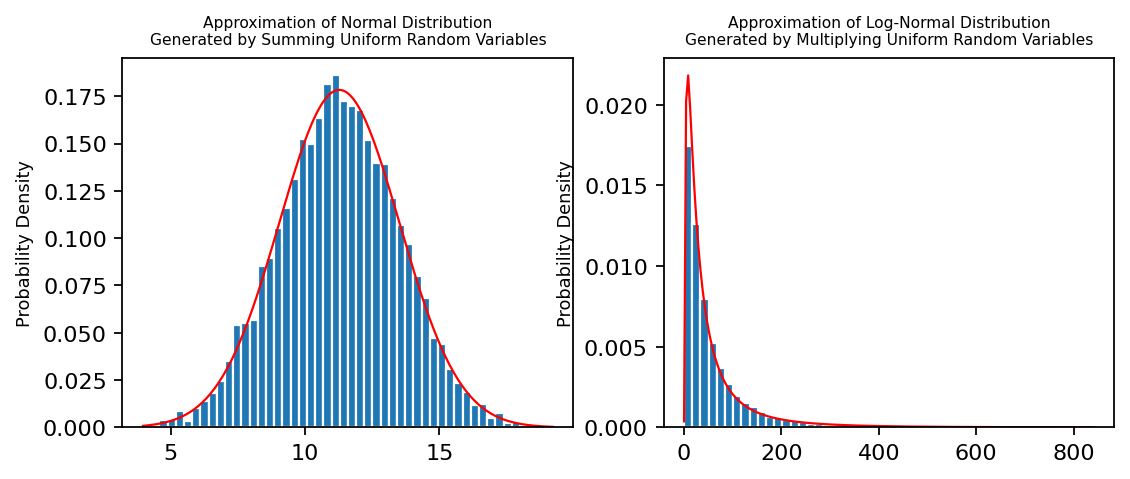

Approximation Normal Distribution Information:
normal_mean: 11.2751   normal_sigma: 2.2371

Approximation Log-Normal Distribution Information:
log_mean (μ of ln(X)): 3.4337    log_sigma (σ of ln(X)): 1.1993


In [57]:

import numpy as np
import matplotlib.pyplot as plt

# ================================================================================
# The Central Limit Theorem (CLT) and Origin of Distributions
# ================================================================================

# Initialize random number generator with a fixed seed for reproducibility
rng = np.random.default_rng(seed=95)

# Lists to store the sums and products of random variables
normal_samples = []          # Store sums of uniform random variables
log_normal_samples = []      # Store products of uniform random variables

# Generate 10,000 samples
for i in range(10000):
    unif_random_number = rng.uniform(low=0.5, high=4.0, size=5)
    
    # By CLT: Sum of many random variables → approaches Normal distribution
    normal_samples.append(np.sum(unif_random_number))
    
    # Product of random variables: By CLT on logarithms → Log-Normal distribution
    log_normal_samples.append(np.prod(unif_random_number))


# Create subplots: left for normal distribution, right for log-normal distribution
fig, ax = plt.subplots(1, 2, figsize=(8, 3), dpi=160)

# ======================== LEFT PANEL: NORMAL DISTRIBUTION ========================

# Plot histogram of the sums from normal_samples
count0, bins0, _ = ax[0].hist(normal_samples, bins=50, density=True, edgecolor=(1, 1, 1))

# Calculate the mean and standard deviation of the sample sums
normal_mean = np.mean(normal_samples)
normal_sigma = np.std(normal_samples)

# Create x-values for the theoretical normal distribution curve
x_normal = np.linspace(start=np.min(bins0), stop=np.max(bins0), num=200)

# Calculate the theoretical PDF of normal distribution: f(x) = (1/(σ*sqrt(2π))) * exp(-(x-μ)²/(2σ²))
pdf_normal = 1 / (normal_sigma * np.sqrt(2 * np.pi)) * np.exp(-((x_normal - normal_mean) ** 2) / (2 * normal_sigma ** 2))

# Overlay the theoretical normal distribution curve on the histogram
ax[0].plot(x_normal, pdf_normal, linewidth=1, color='red')
ax[0].set_title("Approximation of Normal Distribution\nGenerated by Summing Uniform Random Variables", fontsize=7)
ax[0].set_ylabel("Probability Density", fontsize=8)

# ====================== RIGHT PANEL: LOG-NORMAL DISTRIBUTION ====================

# For log-normal distribution, we analyze ln(X) which should be normally distributed
# Calculate mean and std of ln(log_normal_samples)
log_mean = np.mean(np.log(log_normal_samples))
log_sigma = np.std(np.log(log_normal_samples))

# Plot histogram from log_normal_samples
count1, bins1, _ = ax[1].hist(log_normal_samples, bins=50, density=True, edgecolor=(1, 1, 1))

# Create x-values for the theoretical log-normal distribution curve
x_log = np.linspace(start=np.min(bins1), stop=np.max(bins1), num=200)

# Calculate the theoretical PDF of log-normal distribution:
# f(x) = (1/(x*σ*sqrt(2π))) * exp(-(ln(x)-μ)²/(2σ²))
# This is derived from the normal distribution applied to ln(x)
pdf_log = 1 / (x_log * log_sigma * np.sqrt(2 * np.pi)) * np.exp(-((np.log(x_log) - log_mean) ** 2) / (2 * log_sigma ** 2))

# Overlay the theoretical log-normal distribution curve on the histogram
ax[1].plot(x_log, pdf_log, linewidth=1, color="red")
ax[1].set_title("Approximation of Log-Normal Distribution\nGenerated by Multiplying Uniform Random Variables", fontsize=7)
ax[1].set_ylabel("Probability Density", fontsize=8)

plt.show()

# Print the estimated parameters
print(f"Approximation Normal Distribution Information:")
print(f"normal_mean: {normal_mean:.4f}   normal_sigma: {normal_sigma:.4f}")
print(f"\nApproximation Log-Normal Distribution Information:")
print(f"log_mean (μ of ln(X)): {log_mean:.4f}    log_sigma (σ of ln(X)): {log_sigma:.4f}")
